In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Better looking plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Setup Complete ✅")

Setup Complete ✅


In [2]:
DATA_PATH = Path("../data/creditcard.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
#Missing values

missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [5]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 1081


In [6]:
# class distribution

class_counts = df["Class"].value_counts()
class_percent = df["Class"].value_counts(normalize=True) * 100

print(class_counts)
print("\nPercentage:\n")
print(class_percent)

Class
0    284315
1       492
Name: count, dtype: int64

Percentage:

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [7]:
#phase3

## 1. Dataset Overview
Basic statistical summary of the transaction dataset.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### Observation

* The dataset contains **31 numerical features**.
* `Time` and `Amount` are original transaction features.
* `V1–V28` are anonymized PCA-transformed features.
* `Class` is the target variable where `0 = Genuine` and `1 = Fraud`.


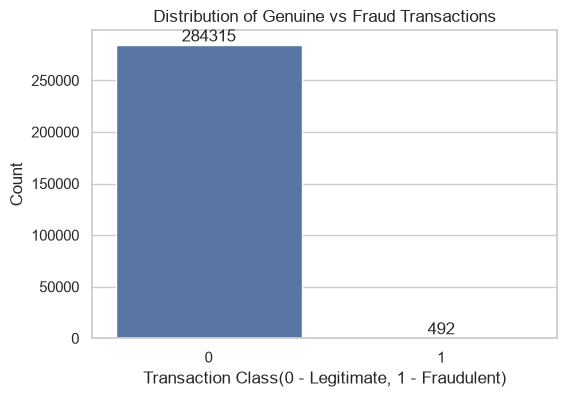

In [9]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="Class")

plt.title("Distribution of Genuine vs Fraud Transactions")
plt.xlabel("Transaction Class(0 - Legitimate, 1 - Fraudulent)")
plt.ylabel("Count")

# Show count values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

* The dataset is **highly imbalanced**.
* Genuine transactions account for **99.83%** of the dataset.
* Fraudulent transactions account for only **0.17%**.
* This means a model predicting every transaction as genuine would achieve very high accuracy but fail to detect fraud.
* Therefore, metrics such as **Precision, Recall and F1-score** are more important than Accuracy.


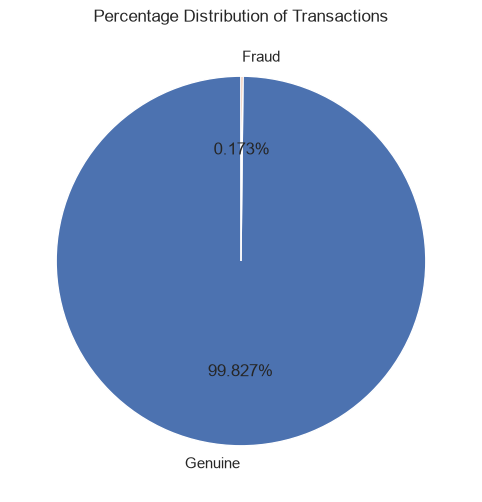

In [10]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    class_counts,
    labels=["Genuine","Fraud"],
    autopct="%1.3f%%",
    startangle=90
)

plt.title("Percentage Distribution of Transactions")

plt.show()

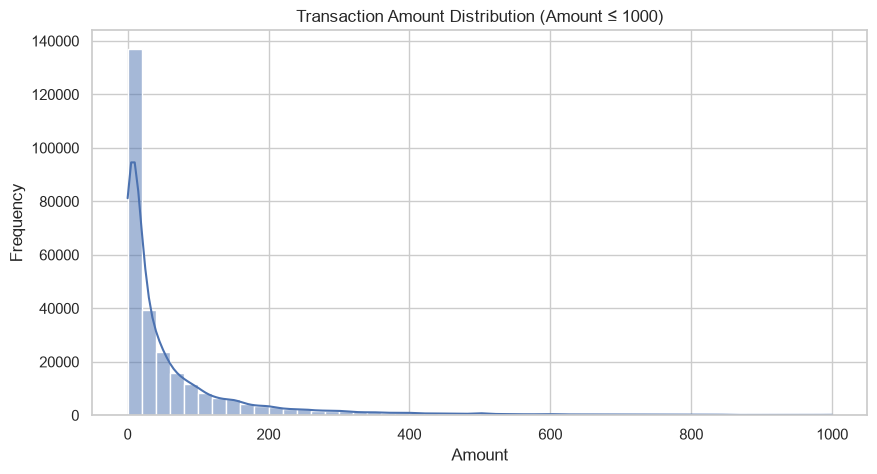

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(df[df["Amount"] <= 1000]["Amount"], bins=50, kde=True)

plt.title("Transaction Amount Distribution (Amount ≤ 1000)")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

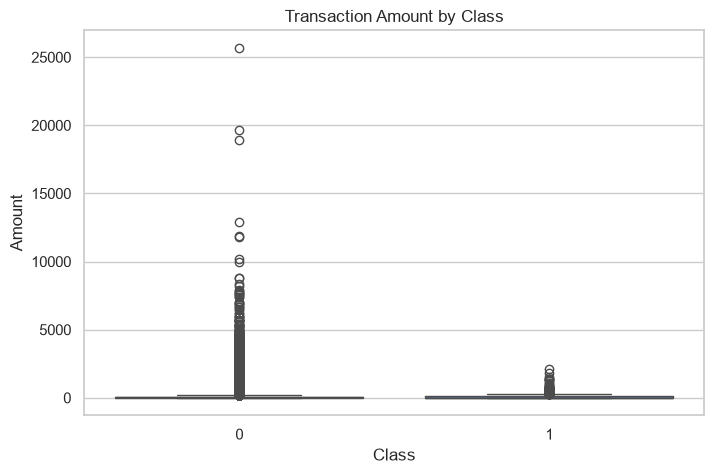

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Class", y="Amount")

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

### Observation

* The dataset spans approximately **48 hours** of transaction activity.
* Two major peaks indicate periods with higher transaction volume during the two-day observation window.
* Lower transaction activity is visible during nighttime hours, suggesting daily behavioral patterns.
* Time alone cannot identify fraud, but it may provide useful contextual information when combined with other features.


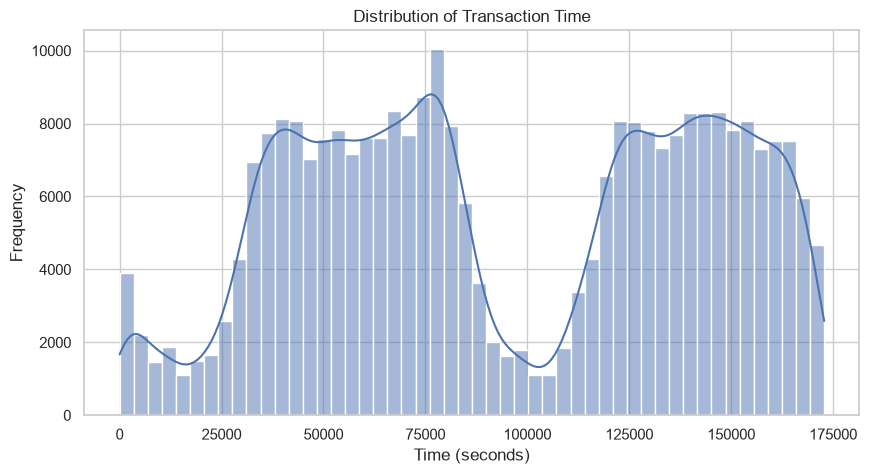

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(df["Time"], bins=50, kde=True)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")

plt.show()

### Observation

* The dataset spans approximately **48 hours** of transaction activity.
* Two major peaks indicate periods with higher transaction volume during the two-day observation window.
* Lower transaction activity is visible during nighttime hours, suggesting daily behavioral patterns.
* Time alone cannot identify fraud, but it may provide useful contextual information when combined with other features.


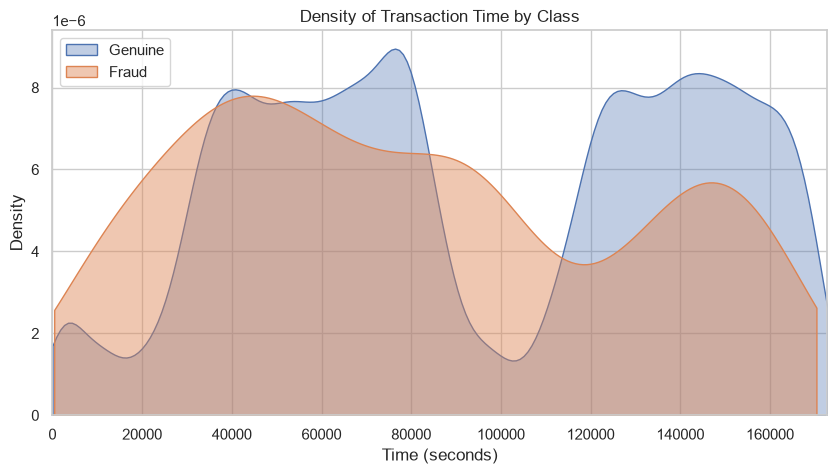

In [14]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df[df["Class"] == 0],
    x="Time",
    label="Genuine",
    fill=True,
    alpha=0.35,
    cut=0,
    clip=(0, df["Time"].max())
)

sns.kdeplot(
    data=df[df["Class"] == 1],
    x="Time",
    label="Fraud",
    fill=True,
    alpha=0.45,
    cut=0,
    clip=(0, df["Time"].max())
)

plt.title("Density of Transaction Time by Class")
plt.xlabel("Time (seconds)")
plt.ylabel("Density")
plt.xlim(0, df["Time"].max())
plt.legend()

plt.show()

In [15]:
df["Hour"] = (df["Time"] / 3600) % 24
df["Hour"] = df["Hour"].astype(int)

df[["Time", "Hour"]].head()

,Time,Hour
0,0.0,0
1,0.0,0
2,1.0,0
3,1.0,0
4,2.0,0


### Observation

The density plot compares the temporal distribution of genuine and fraudulent transactions over the 48-hour observation period. Fraud transactions occur throughout the dataset but exhibit slightly different density peaks compared to genuine transactions. This indicates that transaction timing provides useful behavioral information but cannot independently distinguish fraudulent activity.


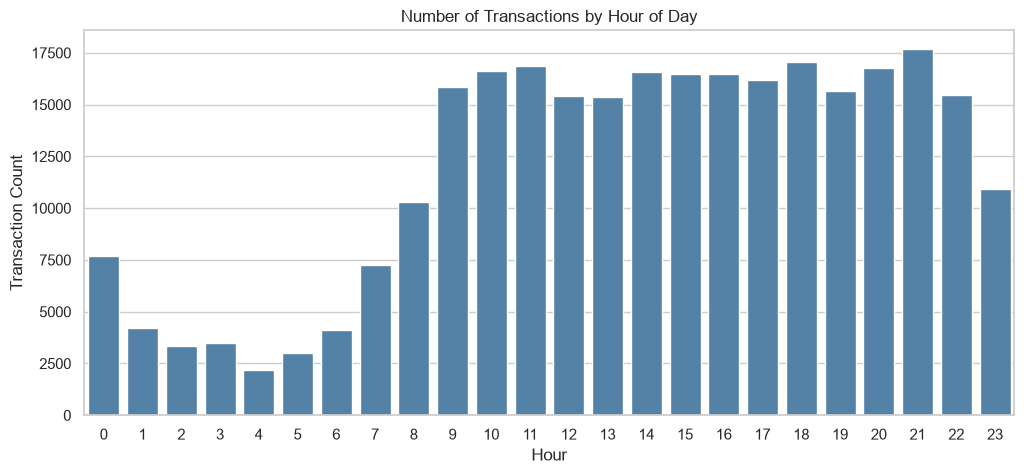

In [16]:
plt.figure(figsize=(12,5))

sns.countplot(data=df, x="Hour", color="steelblue")

plt.title("Number of Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Transaction Count")

plt.show()

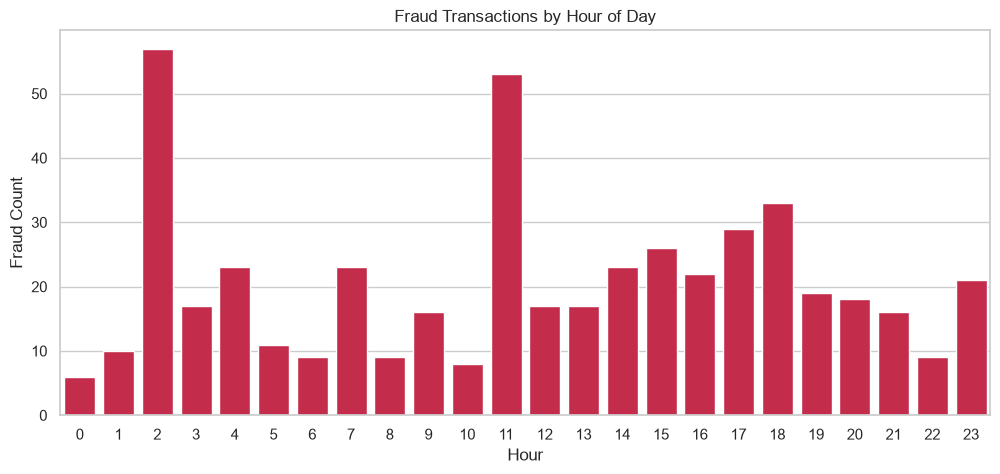

In [17]:
plt.figure(figsize=(12,5))

sns.countplot(data=df[df["Class"] == 1], x="Hour", color="crimson")

plt.title("Fraud Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Fraud Count")

plt.show()

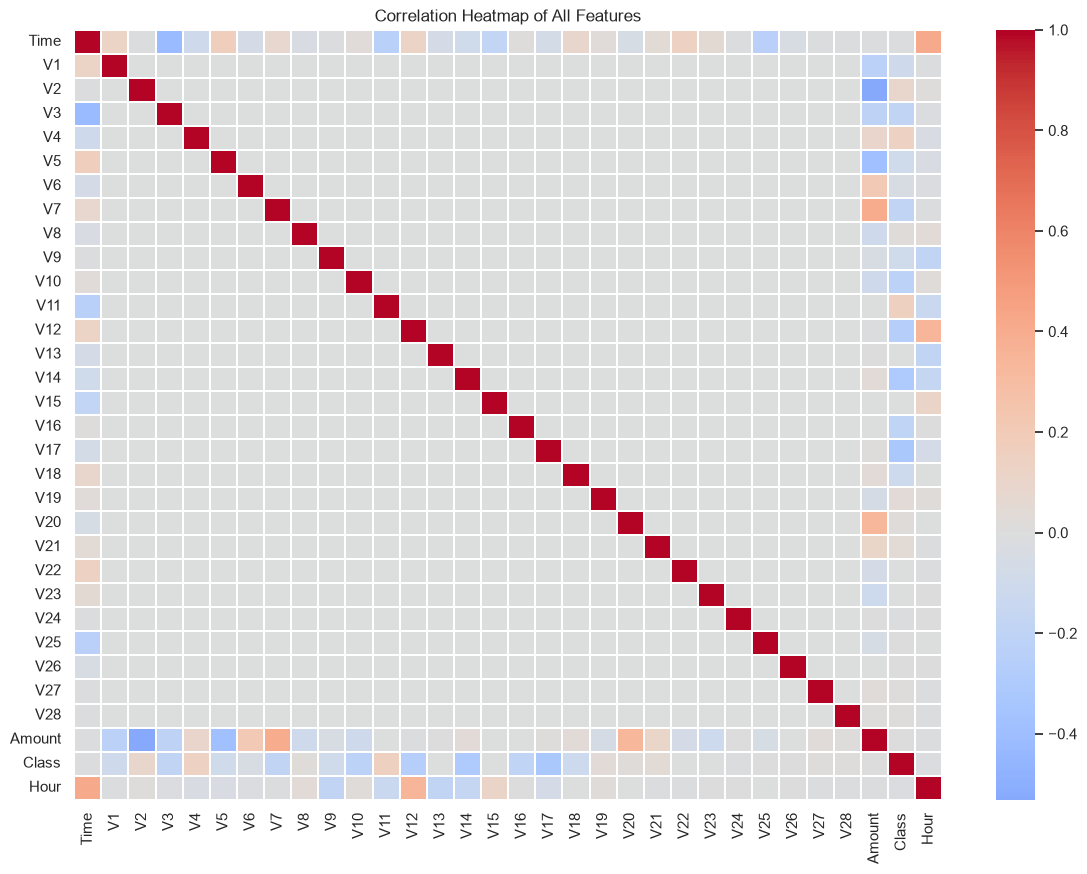

In [18]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Heatmap of All Features")
plt.show()

In [19]:
corr_with_class = (
    corr["Class"]
    .drop("Class")
    .sort_values(key=abs, ascending=False)
)

corr_with_class.head(15)

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
V1    -0.101347
V9    -0.097733
V5    -0.094974
V2     0.091289
V6    -0.043643
Name: Class, dtype: float64

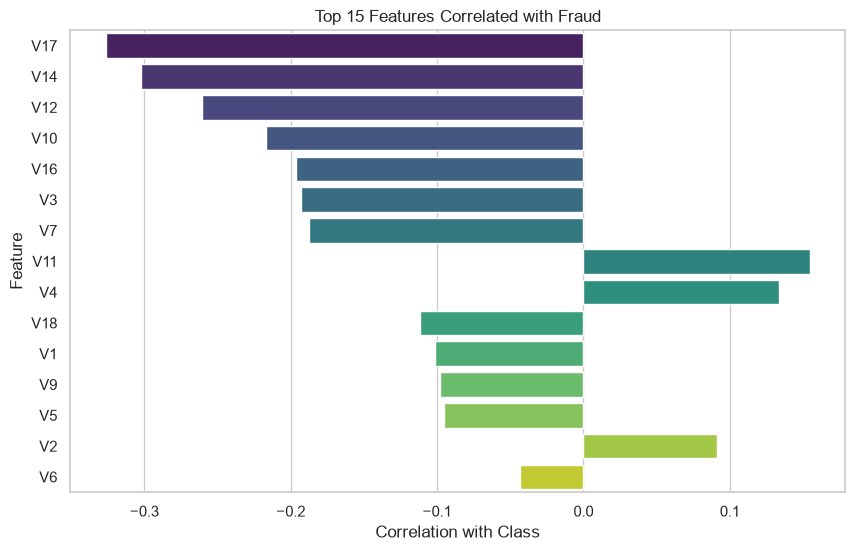

In [20]:
top15 = corr_with_class.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top15.values,
    y=top15.index,
    hue=top15.index,
    palette="viridis",
    legend=False
)

plt.title("Top 15 Features Correlated with Fraud")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.show()

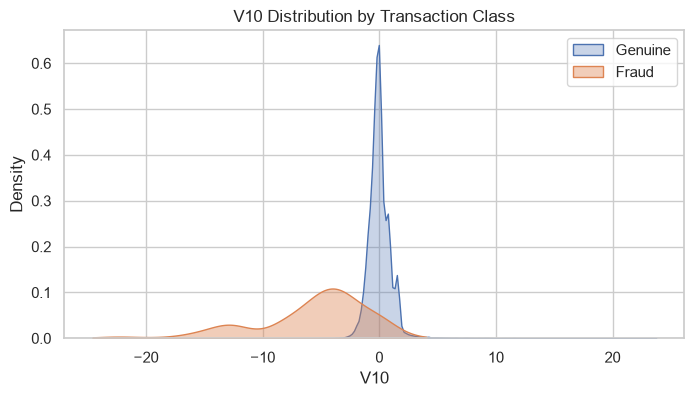

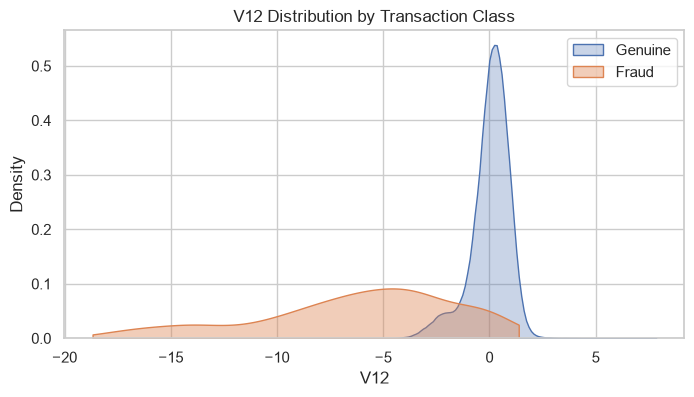

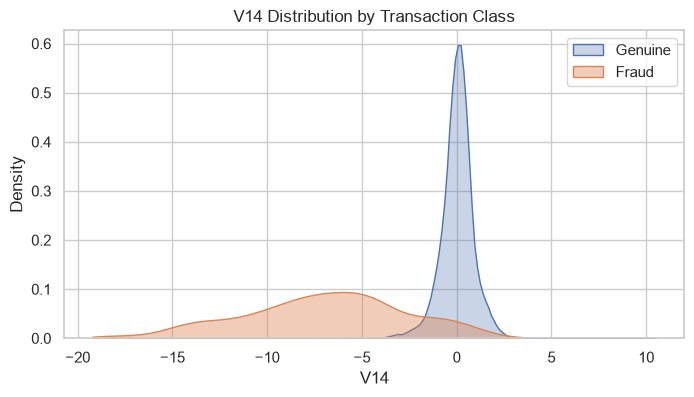

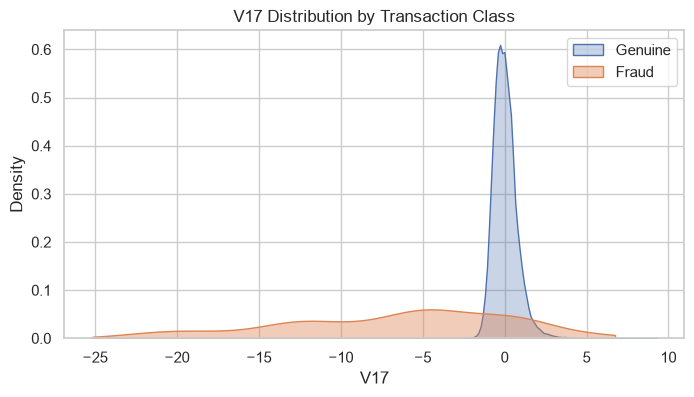

In [21]:
important_features = ["V10", "V12", "V14", "V17"]

for feature in important_features:
    plt.figure(figsize=(8,4))

    sns.kdeplot(
        data=df[df["Class"]==0],
        x=feature,
        fill=True,
        alpha=0.3,
        label="Genuine",
        cut=0
    )

    sns.kdeplot(
        data=df[df["Class"]==1],
        x=feature,
        fill=True,
        alpha=0.4,
        label="Fraud",
        cut=0
    )

    plt.title(f"{feature} Distribution by Transaction Class")
    plt.legend()
    plt.show()

In [22]:
df["Hour"] = ((df["Time"] / 3600) % 24).astype(int)

df[["Time", "Hour"]].head()

,Time,Hour
0,0.0,0
1,0.0,0
2,1.0,0
3,1.0,0
4,2.0,0


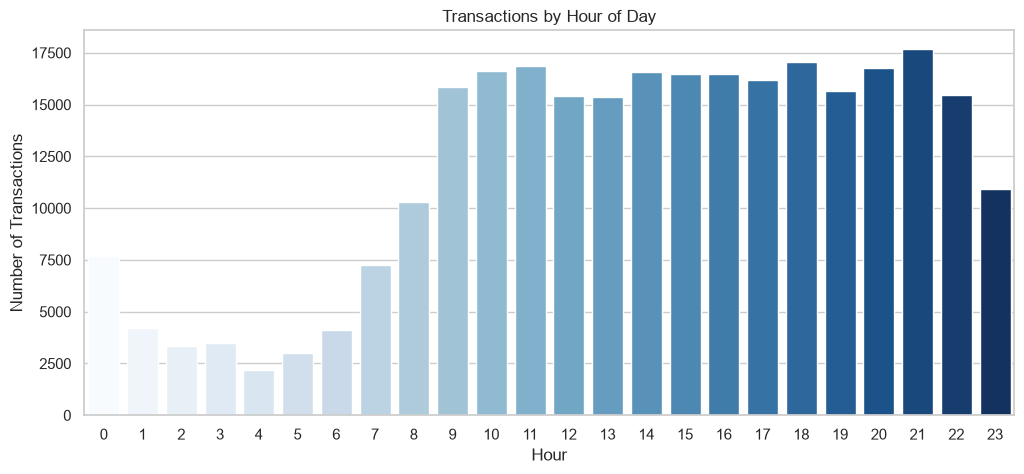

In [23]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Hour",
    hue="Hour",
    palette="Blues",
    legend=False
)

plt.title("Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")

plt.show()

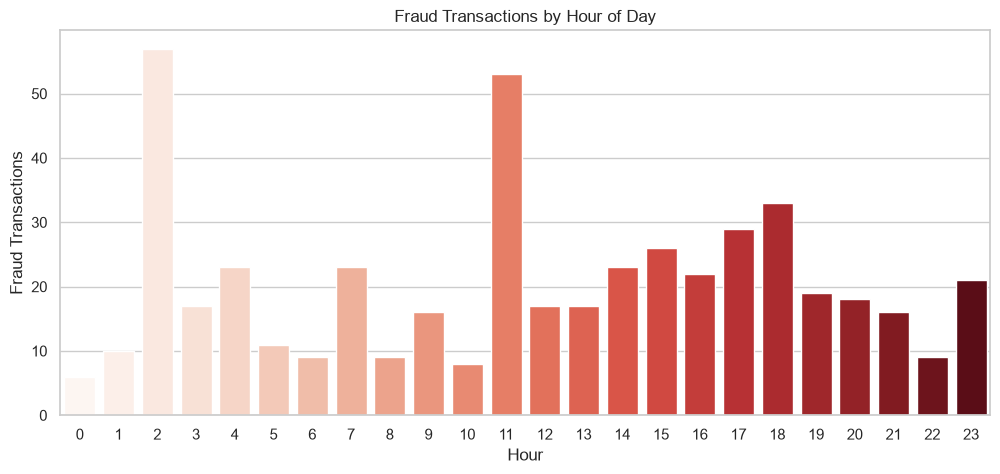

In [24]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df[df["Class"]==1],
    x="Hour",
    hue="Hour",
    palette="Reds",
    legend=False
)

plt.title("Fraud Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Fraud Transactions")

plt.show()

In [25]:
duplicate_rows = df[df.duplicated()]

print("Duplicate rows:", len(duplicate_rows))

duplicate_rows.head()

Duplicate rows: 1081


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0


In [26]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (283726, 32)


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [28]:
target = "Class"

X = df.drop(columns=[target])
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (283726, 31)
Target shape: (283726,)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nFraud ratio in Training set:")
print(y_train.value_counts(normalize=True) * 100)

print("\nFraud ratio in Testing set:")
print(y_test.value_counts(normalize=True) * 100)

Training set shape: (226980, 31)
Testing set shape: (56746, 31)

Fraud ratio in Training set:
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Fraud ratio in Testing set:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


In [30]:
scaler = StandardScaler()

scale_cols = ["Time", "Amount"]

X_train = X_train.copy()
X_test = X_test.copy()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

print("Scaling completed successfully.")

print("\nTraining data - scaled columns:")
print(X_train[scale_cols].describe())

print("\nTesting data - scaled columns:")
print(X_test[scale_cols].describe())

Scaling completed successfully.

Training data - scaled columns:
               Time        Amount
count  2.269800e+05  2.269800e+05
mean  -1.522636e-16  7.487965e-17
std    1.000002e+00  1.000002e+00
min   -1.998400e+00 -3.596386e-01
25%   -8.561822e-01 -3.364866e-01
50%   -2.123526e-01 -2.697972e-01
75%    9.363191e-01 -4.287453e-02
max    1.640237e+00  7.962087e+01

Testing data - scaled columns:
               Time        Amount
count  56746.000000  56746.000000
mean      -0.009386      0.001741
std        0.999221      1.091001
min       -1.998358     -0.359639
25%       -0.860031     -0.337300
50%       -0.219639     -0.271811
75%        0.929386     -0.048378
max        1.640111    104.175192


In [31]:
print("Class distribution in training set:")
print(y_train.value_counts())

print("\nClass distribution in testing set:")
print(y_test.value_counts())

print("\nFraud percentage:")
print("Training:", y_train.mean() * 100, "%")
print("Testing :", y_test.mean() * 100, "%")

Class distribution in training set:
Class
0    226602
1       378
Name: count, dtype: int64

Class distribution in testing set:
Class
0    56651
1       95
Name: count, dtype: int64

Fraud percentage:
Training: 0.16653449643140364 %
Testing : 0.16741268107003138 %


In [32]:
print("Number of features:", X_train.shape[1])

print("\nFeature columns:")
print(X_train.columns.tolist())

Number of features: 31

Feature columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour']


In [33]:
print("Missing values in training data:")
print(X_train.isnull().sum().sum())

print("\nMissing values in testing data:")
print(X_test.isnull().sum().sum())

Missing values in training data:
0

Missing values in testing data:
0


In [34]:
#model training

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [38]:
# Train all models

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42,
        max_depth=8
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train, y_train)

    trained_models[name] = model

print("\nAll models trained successfully.")

Training Logistic Regression...
Training Decision Tree...
Training KNN...

All models trained successfully.


In [39]:
predictions = {}
probabilities = {}

for name, model in trained_models.items():
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name in trained_models:
    y_pred = predictions[name]
    y_prob = probabilities[name]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.9748     0.0553  0.8737    0.1040   0.9684
1        Decision Tree    0.9913     0.1374  0.8000    0.2346   0.9074
2                  KNN    0.9994     0.9420  0.6842    0.7927   0.8841


In [41]:
best_model_name = results_df.loc[
    results_df["ROC-AUC"].idxmax(), "Model"
]

best_model = trained_models[best_model_name]

print("Selected model:", best_model_name)
print("Selection criterion: Highest ROC-AUC")
print("ROC-AUC:", results_df.loc[
    results_df["Model"] == best_model_name, "ROC-AUC"
].iloc[0])

Selected model: Logistic Regression
Selection criterion: Highest ROC-AUC
ROC-AUC: 0.9684420491485727


In [42]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_final = predictions[best_model_name]

print("Classification Report:")
print(classification_report(y_test, y_pred_final, zero_division=0))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_final)
print(cm)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.06      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.97      0.99     56746


Confusion Matrix:
[[55233  1418]
 [   12    83]]


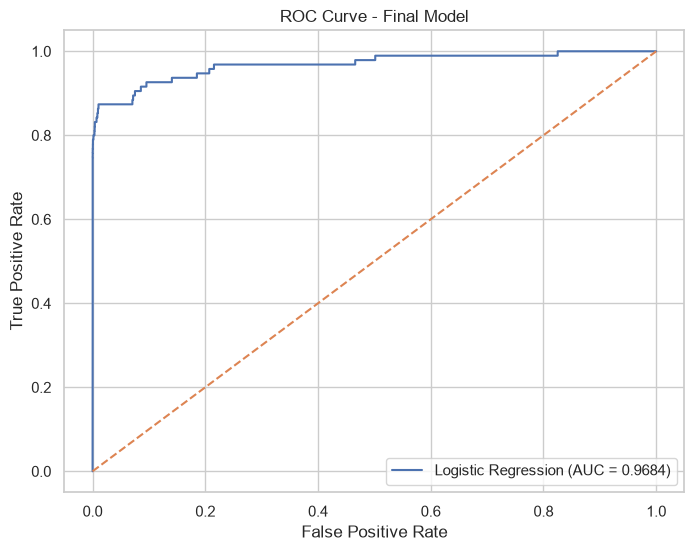

ROC-AUC: 0.9684


In [43]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_final = probabilities[best_model_name]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)
roc_auc = roc_auc_score(y_test, y_prob_final)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")

<Figure size 600x500 with 0 Axes>

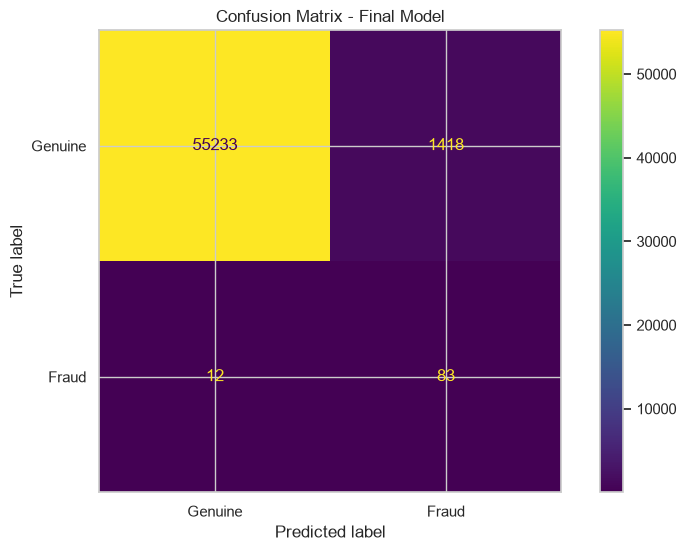

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Fraud"]
).plot(values_format="d")

plt.title("Confusion Matrix - Final Model")
plt.show()

In [45]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("Final model saved successfully.")
print("Scaler saved successfully.")

Final model saved successfully.
Scaler saved successfully.


In [46]:
import os

print("Model exists:", os.path.exists("../models/model.pkl"))
print("Scaler exists:", os.path.exists("../models/scaler.pkl"))

print("\nModel path:", "../models/model.pkl")
print("Scaler path:", "../models/scaler.pkl")

Model exists: True
Scaler exists: True

Model path: ../models/model.pkl
Scaler path: ../models/scaler.pkl


In [47]:
import joblib

loaded_model = joblib.load("../models/model.pkl")
loaded_scaler = joblib.load("../models/scaler.pkl")

test_prediction = loaded_model.predict(X_test.iloc[:5])

print("Model loaded successfully.")
print("Scaler loaded successfully.")
print("Test predictions:", test_prediction)

Model loaded successfully.
Scaler loaded successfully.
Test predictions: [0 0 0 0 0]


In [48]:
print("FINAL MODEL SUMMARY")
print("-" * 40)
print("Model:", best_model_name)
print("Selection criterion: Highest ROC-AUC")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_final, zero_division=0):.4f}")

FINAL MODEL SUMMARY
----------------------------------------
Model: Logistic Regression
Selection criterion: Highest ROC-AUC
ROC-AUC: 0.9684
Accuracy: 0.9748
Precision: 0.0553
Recall: 0.8737
F1-Score: 0.1040
